## 1. Setup and Configuration

In [1]:
import os
import numpy as np
import cv2
import random
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import StringLookup
from tensorflow.keras.callbacks import Callback, EarlyStopping

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Configuration
BASE_PATH = os.getcwd()
DATA_PATH = '/content/drive/MyDrive/ArabicMultiFontsDataset'
MODEL_PATH = os.path.join(BASE_PATH, 'model')
OUTPUT_PATH = os.path.join(BASE_PATH, 'output')

# Dataset files
BASE_FILENAME = "1_nice_60000_rows"
BINARY_FILE = os.path.join(DATA_PATH, BASE_FILENAME + ".bin")
LABELS_FILE = os.path.join(DATA_PATH, BASE_FILENAME + ".txt")

# Image settings - CHANGED FOR RESNET50
IMAGE_WIDTH = 80   # ResNet50 expects smaller width
IMAGE_HEIGHT = 35  # ResNet50 expects smaller height
MAX_TEXT_LENGTH = 32

# Training settings
BATCH_SIZE = 4  # Small batch for GPU memory
EPOCHS = 10
LEARNING_RATE = 0.0001

# Create directories
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Binary file: {BINARY_FILE}")
print(f"Labels file: {LABELS_FILE}")
print(f"Image size: {IMAGE_WIDTH}x{IMAGE_HEIGHT} (RGB)")

Binary file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.bin
Labels file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.txt
Image size: 80x35 (RGB)


## 2. Load and Parse Dataset

In [4]:
class Sample:
    """Represents a single image sample"""
    def __init__(self, gt_text, image_idx, image_height, image_width,
                 image_size, image_start_position):
        self.gtText = gt_text
        self.imageIdx = image_idx
        self.imageHeight = image_height
        self.imageWidth = image_width
        self.imageSize = image_size
        self.imageStartPosition = image_start_position

In [5]:
def parse_labels_file(labels_file):
    """Parse labels file and extract image metadata"""
    samples = []

    print(f"Parsing labels file: {labels_file}")

    with open(labels_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(';')

            if len(parts) < 9:
                continue

            image_idx = parts[0].split(':')[1] if ':' in parts[0] else parts[0]
            start_pos = int(parts[1].split(':')[1]) if ':' in parts[1] else 0
            height = int(parts[2].split(':')[1]) if ':' in parts[2] else 32
            width = int(parts[3].split(':')[1]) if ':' in parts[3] else 128
            size = height * width
            text = parts[8].split(':')[1] if ':' in parts[8] else ''

            samples.append(Sample(text, image_idx, height, width, size, start_pos))

    print(f"✓ Parsed {len(samples)} samples")
    return samples

samples = parse_labels_file(LABELS_FILE)

Parsing labels file: /content/drive/MyDrive/ArabicMultiFontsDataset/1_nice_60000_rows.txt
✓ Parsed 60000 samples


## 3. Preprocessing for ResNet50

In [6]:
def extract_image_from_binary(binary_file, sample):
    """Extract a single image from binary file"""
    binary_file.seek(sample.imageStartPosition)
    img_bytes = binary_file.read(sample.imageSize)
    img = np.frombuffer(img_bytes, dtype=np.uint8)
    img = img.reshape(sample.imageHeight, sample.imageWidth)
    return img

In [7]:
def resize_with_padding(img, target_size=(80, 35)):
    """
    Resize image with padding (maintains aspect ratio)
    Returns RGB image for ResNet50
    """
    target_width, target_height = target_size

    # Convert grayscale to PIL Image
    if len(img.shape) == 2:
        img = Image.fromarray(img, mode='L').convert('RGB')
    else:
        img = Image.fromarray(img)

    original_width, original_height = img.size

    # Calculate ratio
    ratio = min(target_width / original_width, target_height / original_height)
    new_size = (int(original_width * ratio), int(original_height * ratio))
    resized = img.resize(new_size, Image.Resampling.LANCZOS)

    # Add white padding
    padded_img = Image.new('RGB', (target_width, target_height), (255, 255, 255))
    paste_position = ((target_width - new_size[0]) // 2, (target_height - new_size[1]) // 2)
    padded_img.paste(resized, paste_position)

    return np.array(padded_img)


Testing preprocessing...


/tmp/ipykernel_4452/1983940331.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L').convert('RGB')


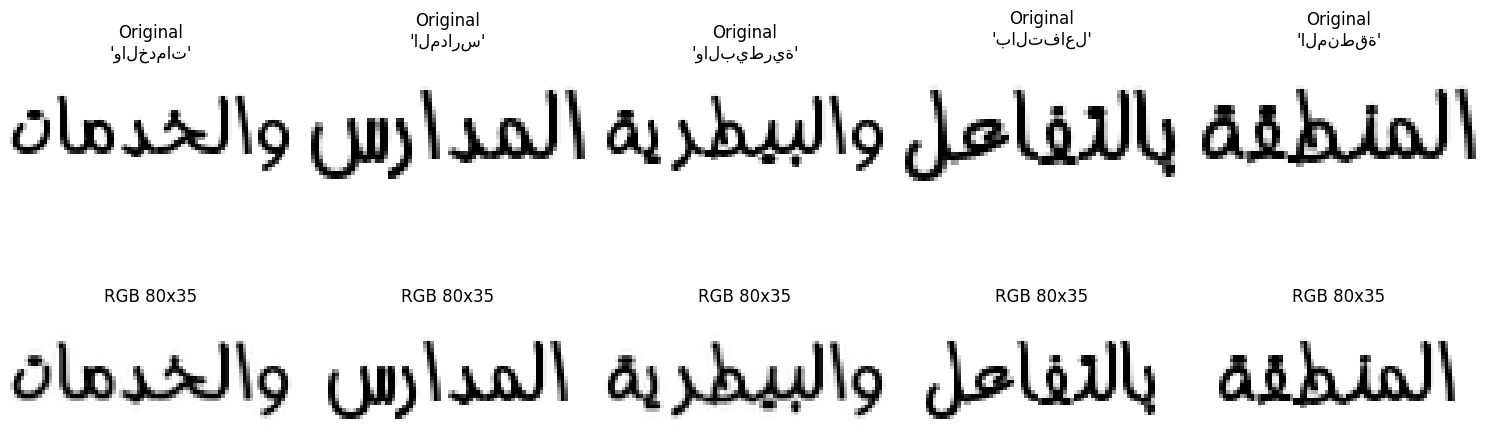

✓ Preprocessing works correctly


In [8]:
# Test preprocessing
print("\nTesting preprocessing...")
with open(BINARY_FILE, 'rb') as f:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i in range(5):
        # Original
        original = extract_image_from_binary(f, samples[i])
        axes[0, i].imshow(original, cmap='gray')
        axes[0, i].set_title(f"Original\n'{samples[i].gtText}'")
        axes[0, i].axis('off')

        # Preprocessed
        preprocessed = resize_with_padding(original, (IMAGE_WIDTH, IMAGE_HEIGHT))
        axes[1, i].imshow(preprocessed)
        axes[1, i].set_title(f"RGB {IMAGE_WIDTH}x{IMAGE_HEIGHT}")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

print("✓ Preprocessing works correctly")

## 4. Prepare Dataset

In [10]:
# Shuffle and split
random.shuffle(samples)

total = len(samples)
train_size = int(0.7 * total)
val_size = int(0.05 * total)

train_samples = samples[:train_size]
val_samples = samples[train_size:train_size + val_size]
test_samples = samples[train_size + val_size:]

print(f"Dataset split:")
print(f"  Training:   {len(train_samples)} samples")
print(f"  Validation: {len(val_samples)} samples")
print(f"  Testing:    {len(test_samples)} samples")

Dataset split:
  Training:   42000 samples
  Validation: 3000 samples
  Testing:    15000 samples


In [11]:
# Create character vocabulary
chars_set = set()
for sample in samples:
    chars_set = chars_set.union(set(list(sample.gtText)))

char_list = sorted(list(chars_set))

print(f"✓ Character vocabulary: {len(char_list)} unique characters")
print(f"  Sample: {char_list[:20]}")

✓ Character vocabulary: 45 unique characters
  Sample: [' ', 'ء', 'آ', 'أ', 'ؤ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س']


In [12]:
# Create StringLookup layers
char_to_num = StringLookup(vocabulary=char_list, mask_token=None)
num_to_char = StringLookup(
    vocabulary=char_to_num.get_vocabulary(),
    mask_token=None,
    invert=True
)

print(f"✓ StringLookup layers created")
print(f"  Vocabulary size: {len(char_to_num.get_vocabulary())}")

✓ StringLookup layers created
  Vocabulary size: 46


## 5. Data Generator

In [13]:
def data_generator(binary_file_path, samples, batch_size, char_to_num):
    """
    Generator that yields batches of (images, labels)
    """
    with open(binary_file_path, 'rb') as f:
        num_samples = len(samples)
        indices = list(range(num_samples))

        while True:
            random.shuffle(indices)

            for start_idx in range(0, num_samples, batch_size):
                end_idx = min(start_idx + batch_size, num_samples)
                batch_indices = indices[start_idx:end_idx]

                images = []
                labels = []

                for idx in batch_indices:
                    sample = samples[idx]

                    # Extract and preprocess image
                    img = extract_image_from_binary(f, sample)
                    img = resize_with_padding(img, (IMAGE_WIDTH, IMAGE_HEIGHT))

                    # Apply ResNet preprocessing
                    img = tf.keras.applications.resnet50.preprocess_input(img)

                    images.append(img)
                    labels.append(sample.gtText)

                # Convert to tensors
                images = np.array(images, dtype=np.float32)

                # Encode labels
                encoded_labels = []
                for label in labels:
                    chars = tf.strings.unicode_split(label, input_encoding="UTF-8")
                    encoded = char_to_num(chars)
                    encoded_labels.append(encoded.numpy())

                # Pad labels
                max_len = max(len(l) for l in encoded_labels)
                padded_labels = np.zeros((len(encoded_labels), max_len), dtype=np.float32)
                for i, label in enumerate(encoded_labels):
                    padded_labels[i, :len(label)] = label

                yield {"image": images, "label": padded_labels}

In [14]:
# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(BINARY_FILE, train_samples, BATCH_SIZE, char_to_num),
    output_signature={
        "image": tf.TensorSpec(shape=(None, IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=tf.float32),
        "label": tf.TensorSpec(shape=(None, None), dtype=tf.float32)
    }
).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(BINARY_FILE, val_samples, BATCH_SIZE, char_to_num),
    output_signature={
        "image": tf.TensorSpec(shape=(None, IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=tf.float32),
        "label": tf.TensorSpec(shape=(None, None), dtype=tf.float32)
    }
).prefetch(tf.data.AUTOTUNE)

print("✓ TensorFlow datasets created")

✓ TensorFlow datasets created


## 6. Build Model - ResNet50 + 4 Stacked BiLSTMs

In [15]:
class CTCLayer(keras.layers.Layer):
    """CTC Loss Layer"""
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
        label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

        input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)

        return y_pred

In [16]:
def build_resnet50_deep_lstm_model():
    """
    Build ResNet50 + 4 Stacked BiLSTMs model

    Architecture:
    - ResNet50 (pretrained ImageNet, frozen)
    - Resizing layer
    - Reshape
    - Dense(64) + BatchNorm + Dropout(0.5)
    - 4x Bidirectional LSTM (512→256→128→64)
    - Dense(vocab_size + 1) + Softmax
    - CTC Loss
    """
    # ResNet50 backbone
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
    )

    # Freeze ResNet
    base_model.trainable = False

    # Input layers
    imgs = tf.keras.layers.Input(
        shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
        name="image",
        dtype="float32"
    )
    labels = tf.keras.layers.Input(name="label", shape=(None,), dtype="float32")

    # Feature extraction
    x = base_model(imgs, training=False)
    x = keras.layers.Resizing(15, 20)(x)

    # Reshape for RNN
    new_shape = (x.shape[2], x.shape[1] * x.shape[3])
    x = tf.keras.layers.Reshape(new_shape, name="reshape")(x)

    # Dense + Regularization
    x = tf.keras.layers.Dense(64, activation="relu", name="dense1")(x)
    x = tf.keras.layers.BatchNormalization(name="batch_norm")(x)
    x = tf.keras.layers.Dropout(0.5, name="dropout")(x)

    # 4 Stacked Bidirectional LSTMs
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(512, return_sequences=True),
        name="bilstm_1"
    )(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(256, return_sequences=True),
        name="bilstm_2"
    )(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128, return_sequences=True),
        name="bilstm_3"
    )(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True),
        name="bilstm_4"
    )(x)

    # Output layer
    x = tf.keras.layers.Dense(
        len(char_to_num.get_vocabulary()) + 1,
        activation="softmax",
        name="dense_output"
    )(x)

    # CTC loss
    output = CTCLayer(name="ctc_loss")(labels, x)

    # Build model
    model = tf.keras.models.Model(
        inputs=[imgs, labels],
        outputs=output,
        name="resnet50_deep_lstm_ocr"
    )

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            clipvalue=1.0  # Gradient clipping
        )
    )

    return model

In [17]:
# Build model
print("\n" + "="*70)
print("BUILDING MODEL: ResNet50 + 4 Stacked BiLSTMs")
print("="*70)

model = build_resnet50_deep_lstm_model()
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n✓ Model built successfully")
print(f"  Total parameters: {total_params:,}")
print("="*70)


BUILDING MODEL: ResNet50 + 4 Stacked BiLSTMs
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "resnet50_deep_lstm_ocr"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 35, 80, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2, 3,      │ 23,587,712 │ image[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 15, 20,    │          0 │ resnet50[0][0]    │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 20, 30720) │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 20, 64)    │  1,966,144 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm          │ (None, 20, 64)    │        256 │ dense1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 64)    │          0 │ batch_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 20, 1024)  │  2,363,392 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 20, 512)   │  2,623,488 │ bilstm_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_3            │ (None, 20, 256)   │    656,384 │ bilstm_2[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_4            │ (None, 20, 128)   │    164,352 │ bilstm_3[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_output        │ (None, 20, 47)    │      6,063 │ bilstm_4[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_loss (CTCLayer) │ (None, 20, 47)    │          0 │ label[0][0],      │
│                     │                   │            │ dense_output[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,367,791 (119.66 MB)

 Trainable params: 7,779,951 (29.68 MB)

 Non-trainable params: 23,587,840 (89.98 MB)


✓ Model built successfully
  Total parameters: 31,367,791


## 7. Training Callbacks

In [18]:
class BatchLossLogger(Callback):
    """Log loss per batch"""
    def on_train_begin(self, logs=None):
        self.batch_losses = []

    def on_train_batch_end(self, batch, logs=None):
        self.batch_losses.append(logs.get("loss"))

In [19]:
# Setup callbacks
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

batch_loss_logger = BatchLossLogger()

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_PATH, "resnet50_deep_lstm_{epoch:02d}.weights.h5"),
    save_weights_only=True,
    save_best_only=True,
    monitor="val_loss",
    verbose=1
)

print("✓ Callbacks configured")

✓ Callbacks configured


## 8. Train Model

In [20]:
print("\n" + "="*70)
print("TRAINING MODEL")
print("="*70)

# Calculate steps per epoch
steps_per_epoch = len(train_samples) // BATCH_SIZE
validation_steps = len(val_samples) // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print("="*70 + "\n")

# Train
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[batch_loss_logger, early_stopping, checkpoint_callback],
    verbose=1
)

print("\n✓ Training completed")


TRAINING MODEL
Steps per epoch: 10500
Validation steps: 750
Batch size: 4
Epochs: 10

Epoch 1/10


/tmp/ipykernel_4452/1983940331.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L').convert('RGB')


10499/10500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 81.6501
Epoch 1: val_loss improved from None to 61.24018, saving model to /content/model/resnet50_deep_lstm_01.weights.h5

Epoch 1: finished saving model to /content/model/resnet50_deep_lstm_01.weights.h5
10500/10500 ━━━━━━━━━━━━━━━━━━━━ 611s 56ms/step - loss: 71.1049 - val_loss: 61.2402
Epoch 2/10
10499/10500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 58.4403
Epoch 2: val_loss improved from 61.24018 to 52.79173, saving model to /content/model/resnet50_deep_lstm_02.weights.h5

Epoch 2: finished saving model to /content/model/resnet50_deep_lstm_02.weights.h5
10500/10500 ━━━━━━━━━━━━━━━━━━━━ 622s 59ms/step - loss: 56.2933 - val_loss: 52.7917
Epoch 3/10
10500/10500 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 51.1067
Epoch 3: val_loss improved from 52.79173 to 48.14379, saving model to /content/model/resnet50_deep_lstm_03.weights.h5

Epoch 3: finished saving model to /content/model/resnet50_deep_lstm_03.weights.h5
10500/10500 ━━━━━━━━━━━━━

## 9. Save Model

In [21]:
# Save final model
final_model_path = os.path.join(MODEL_PATH, "resnet50_deep_lstm_final.h5")
model.save(final_model_path)
print(f"✓ Model saved to: {final_model_path}")

# Save character lookup layers
char_to_num_path = os.path.join(MODEL_PATH, "char_to_num_layer.keras")
num_to_char_path = os.path.join(MODEL_PATH, "num_to_char_layer.keras")

tf.keras.models.save_model(char_to_num, char_to_num_path)
tf.keras.models.save_model(num_to_char, num_to_char_path)

print(f"✓ Character lookup layers saved")

✓ Model saved to: /content/model/resnet50_deep_lstm_final.h5
✓ Character lookup layers saved


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


## 10. Visualize Training

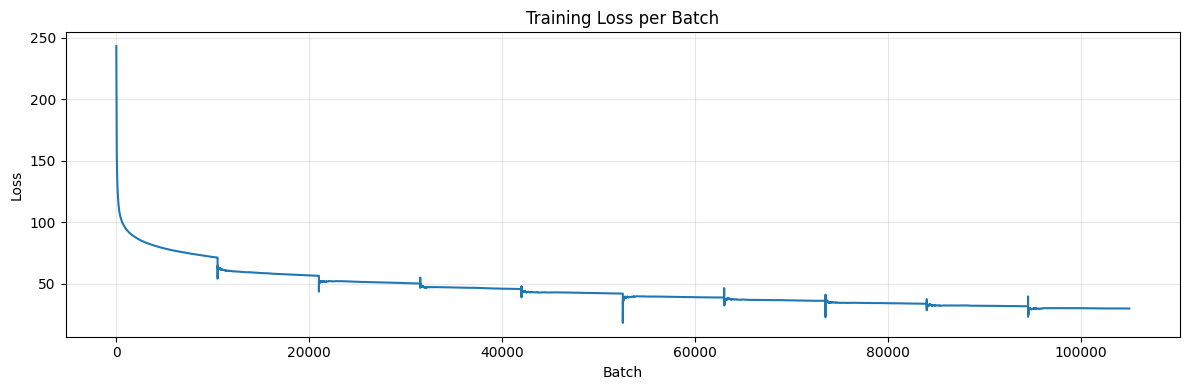

In [22]:
# Plot batch losses
plt.figure(figsize=(12, 4))
plt.plot(batch_loss_logger.batch_losses)
plt.title("Training Loss per Batch")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "batch_losses.png"), dpi=150)
plt.show()

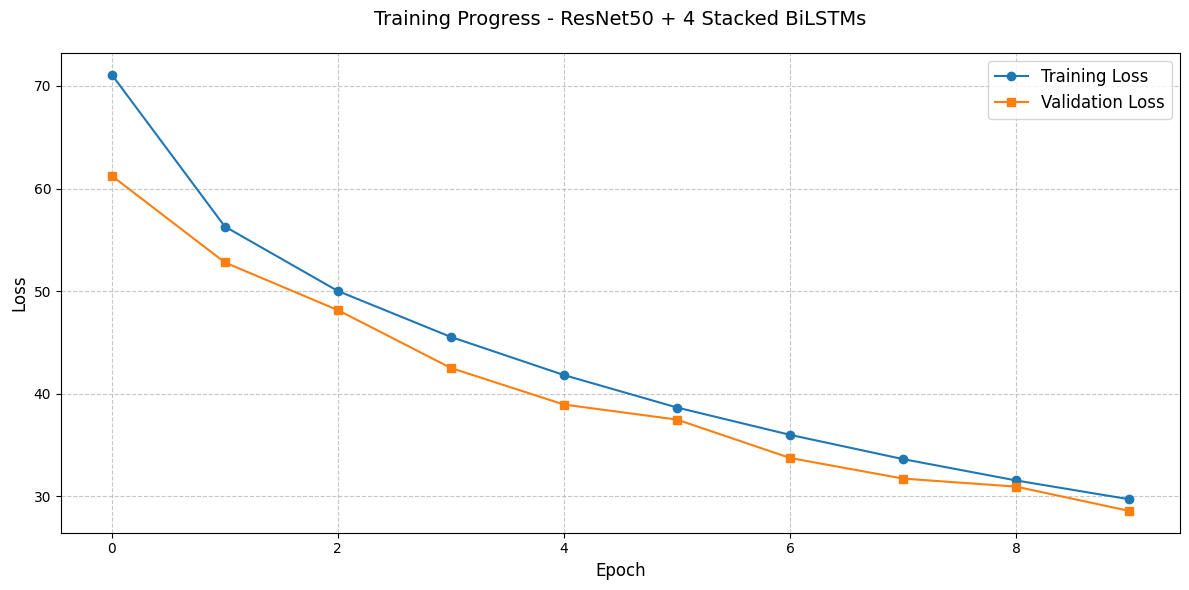

✓ Training visualizations saved


In [23]:
# Plot epoch losses
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Training Loss", marker='o')
plt.plot(history.history["val_loss"], label="Validation Loss", marker='s')
plt.title("Training Progress - ResNet50 + 4 Stacked BiLSTMs", fontsize=14, pad=20)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "training_progress.png"), dpi=150)
plt.show()

print("✓ Training visualizations saved")

## 11. Inference

In [24]:
# Create prediction model (without CTC layer)
prediction_model = keras.models.Model(
    inputs=model.inputs[0],
    outputs=model.get_layer("dense_output").output
)

print("✓ Prediction model created")

✓ Prediction model created


In [25]:
def decode_batch_predictions(pred, num_to_char):
    """Decode CTC predictions with beam search"""
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    # Beam search decoding (width=100)
    results = tf.keras.backend.ctc_decode(
        pred,
        input_length=input_len,
        greedy=False,  # Use beam search
        beam_width=100
    )[0][0]

    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res.replace("[UNK]", ""))

    return output_text


TESTING INFERENCE


/tmp/ipykernel_4452/1983940331.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L').convert('RGB')


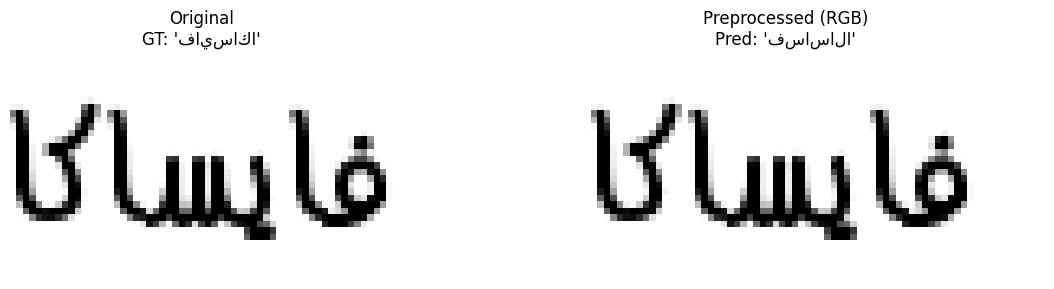

Ground Truth: 'فايساكا'
Prediction:   'فساسالا'
Match: False
----------------------------------------------------------------------


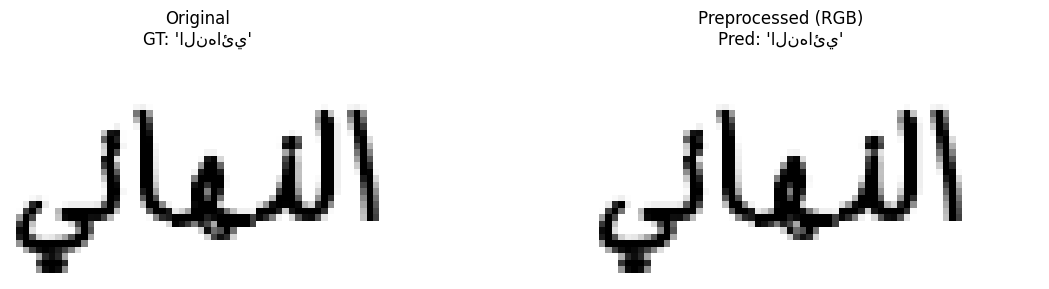

Ground Truth: 'النهائي'
Prediction:   'النهائي'
Match: True
----------------------------------------------------------------------


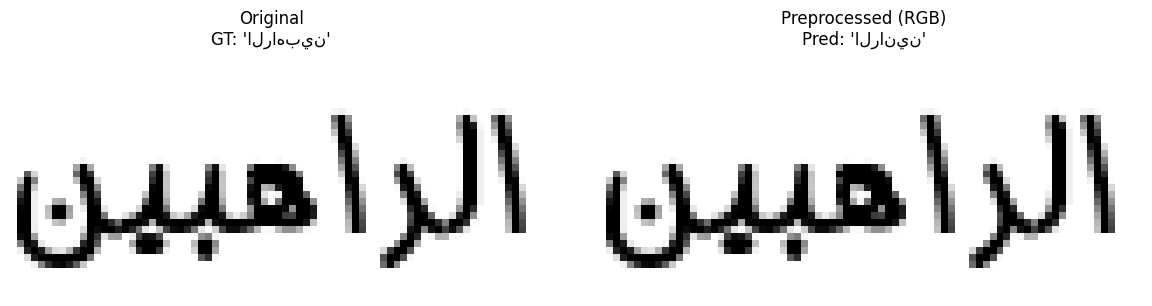

Ground Truth: 'الراهبين'
Prediction:   'الرانين'
Match: False
----------------------------------------------------------------------


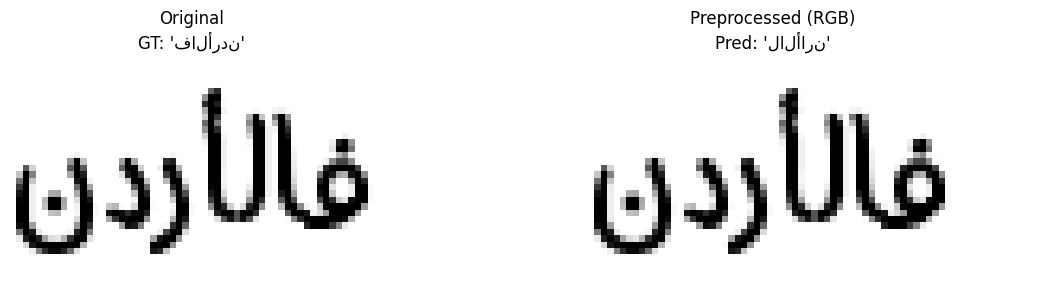

Ground Truth: 'فالأردن'
Prediction:   'لالأارن'
Match: False
----------------------------------------------------------------------


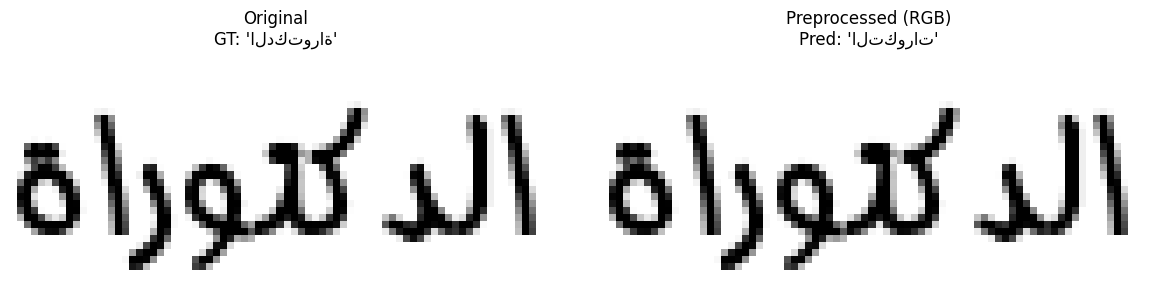

Ground Truth: 'الدكتوراة'
Prediction:   'التكورات'
Match: False
----------------------------------------------------------------------


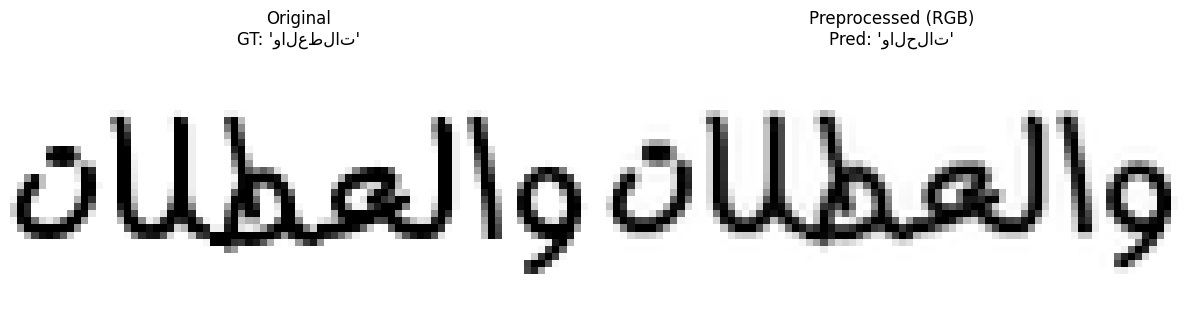

Ground Truth: 'والعطلات'
Prediction:   'والحلات'
Match: False
----------------------------------------------------------------------


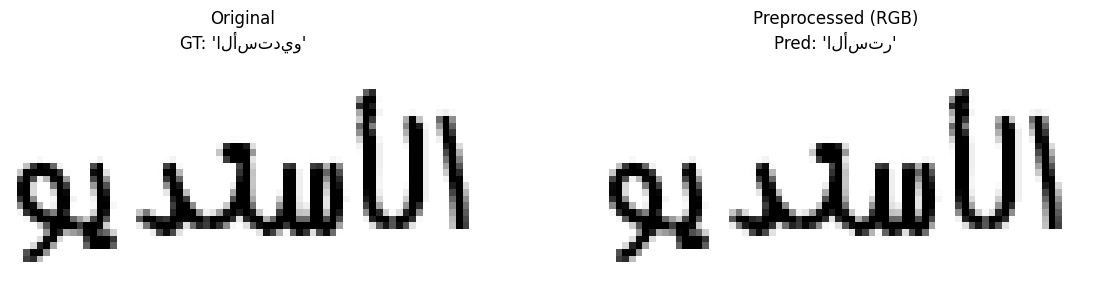

Ground Truth: 'الأستديو'
Prediction:   'الأستر'
Match: False
----------------------------------------------------------------------


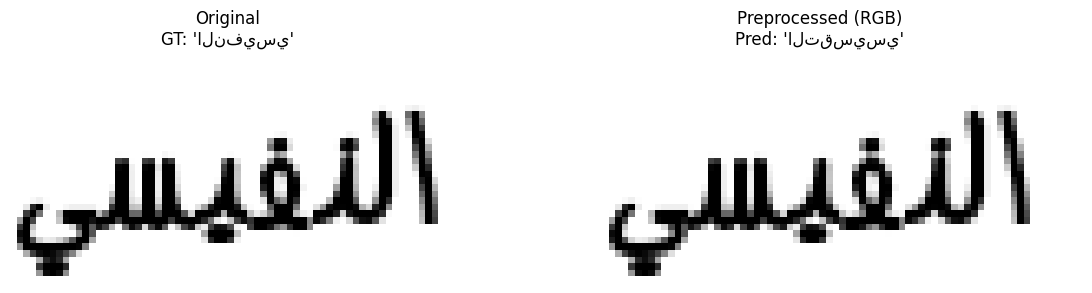

Ground Truth: 'النفيسي'
Prediction:   'التقسيسي'
Match: False
----------------------------------------------------------------------


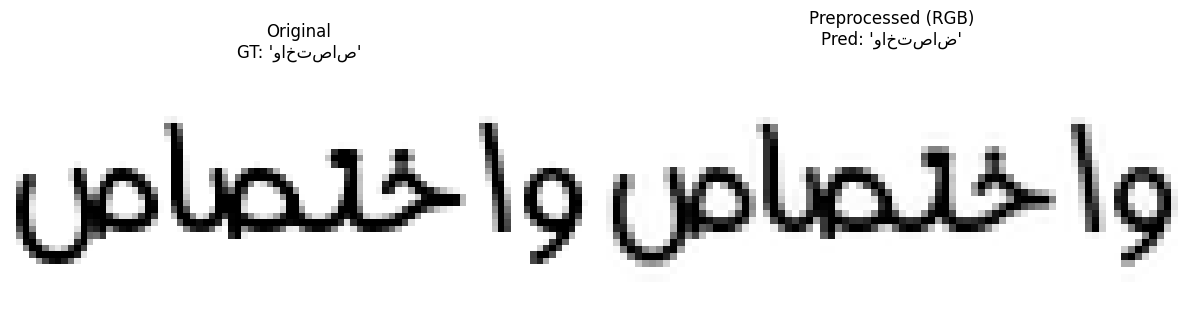

Ground Truth: 'واختصاص'
Prediction:   'واختصاض'
Match: False
----------------------------------------------------------------------


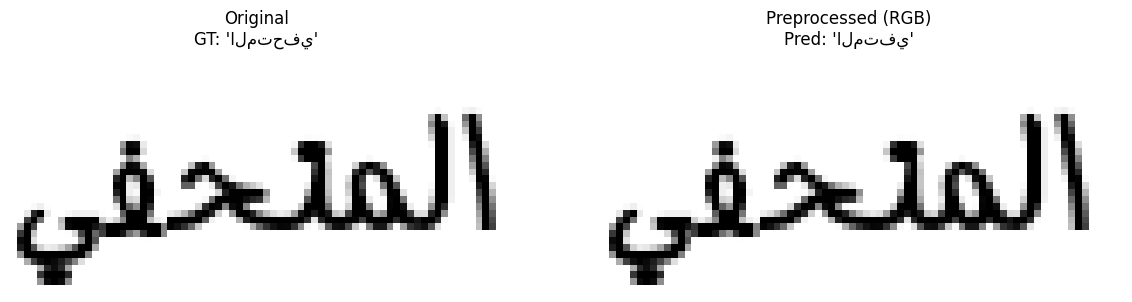

Ground Truth: 'المتحفي'
Prediction:   'المتفي'
Match: False
----------------------------------------------------------------------

✓ Inference testing completed


In [26]:
# Test on validation samples
print("\n" + "="*70)
print("TESTING INFERENCE")
print("="*70)

with open(BINARY_FILE, 'rb') as f:
    # Get 10 random test samples
    test_indices = random.sample(range(len(test_samples)), min(10, len(test_samples)))

    for idx in test_indices:
        sample = test_samples[idx]

        # Extract and preprocess
        img = extract_image_from_binary(f, sample)
        img_rgb = resize_with_padding(img, (IMAGE_WIDTH, IMAGE_HEIGHT))
        img_preprocessed = tf.keras.applications.resnet50.preprocess_input(img_rgb)

        # Predict
        pred = prediction_model.predict(np.expand_dims(img_preprocessed, axis=0), verbose=0)
        pred_text = decode_batch_predictions(pred, num_to_char)[0]

        # Display
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))

        axes[0].imshow(img, cmap='gray')
        axes[0].set_title(f"Original\nGT: '{sample.gtText}'")
        axes[0].axis('off')

        axes[1].imshow(img_rgb)
        axes[1].set_title(f"Preprocessed (RGB)\nPred: '{pred_text}'")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"Ground Truth: '{sample.gtText}'")
        print(f"Prediction:   '{pred_text}'")
        print(f"Match: {sample.gtText == pred_text}")
        print("-" * 70)

print("\n✓ Inference testing completed")

## 12. Evaluate on Test Set

In [27]:
def calculate_edit_distance(str1, str2):
    """Calculate Levenshtein edit distance"""
    m, n = len(str1), len(str2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if str1[i-1] == str2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    return dp[m][n]

In [28]:
print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

total_char_errors = 0
total_chars = 0
correct_predictions = 0
total_predictions = 0

with open(BINARY_FILE, 'rb') as f:
    for i, sample in enumerate(test_samples[:1000]):  # Evaluate on first 1000
        if i % 100 == 0:
            print(f"Progress: {i}/{min(1000, len(test_samples))}")

        # Extract and preprocess
        img = extract_image_from_binary(f, sample)
        img_rgb = resize_with_padding(img, (IMAGE_WIDTH, IMAGE_HEIGHT))
        img_preprocessed = tf.keras.applications.resnet50.preprocess_input(img_rgb)

        # Predict
        pred = prediction_model.predict(np.expand_dims(img_preprocessed, axis=0), verbose=0)
        pred_text = decode_batch_predictions(pred, num_to_char)[0]

        # Calculate metrics
        edit_dist = calculate_edit_distance(sample.gtText, pred_text)
        total_char_errors += edit_dist
        total_chars += len(sample.gtText)

        if sample.gtText == pred_text:
            correct_predictions += 1
        total_predictions += 1

# Calculate metrics
cer = total_char_errors / total_chars if total_chars > 0 else 0
accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)
print(f"Character Error Rate (CER): {cer*100:.2f}%")
print(f"Word Accuracy: {accuracy*100:.2f}%")
print(f"Total samples evaluated: {total_predictions}")
print("="*70)


EVALUATING ON TEST SET
Progress: 0/1000


/tmp/ipykernel_4452/1983940331.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L').convert('RGB')


Progress: 100/1000
Progress: 200/1000
Progress: 300/1000
Progress: 400/1000
Progress: 500/1000
Progress: 600/1000
Progress: 700/1000
Progress: 800/1000
Progress: 900/1000

EVALUATION RESULTS
Character Error Rate (CER): 21.41%
Word Accuracy: 24.30%
Total samples evaluated: 1000
